In [2]:
import torch
import numpy

In [3]:
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
# print("Current GPU:", torch.cuda.current_device())
# print("GPU Name:", torch.cuda.get_device_name(torch.cuda.current_device()))

CUDA available: False
Number of GPUs: 0


In [4]:
scalar = torch.tensor(7)
scalar

tensor(7)

In [5]:
scalar.item()

7

In [6]:
vector = torch.tensor([7,7])
vector
vector.ndim

1

In [7]:
matrix = torch.tensor([[1, 0],
                       [0, 1]])
matrix.ndim

2

In [8]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.6.0'

In [9]:
weight = 0.7
bias = 0.3

start  = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight*X+bias

X[:10], y[:10] # up until 0.980 for X (end exclusive)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [10]:
#create training data

train_split = int(0.8*len(X)) #use 80% of data
X_train = X[:train_split]
y_train = y[:train_split]
X_test=X[train_split:]
y_test= y[train_split:]

len(X_train), len(X_test) #40 for training, 10 for testing

(40, 10)

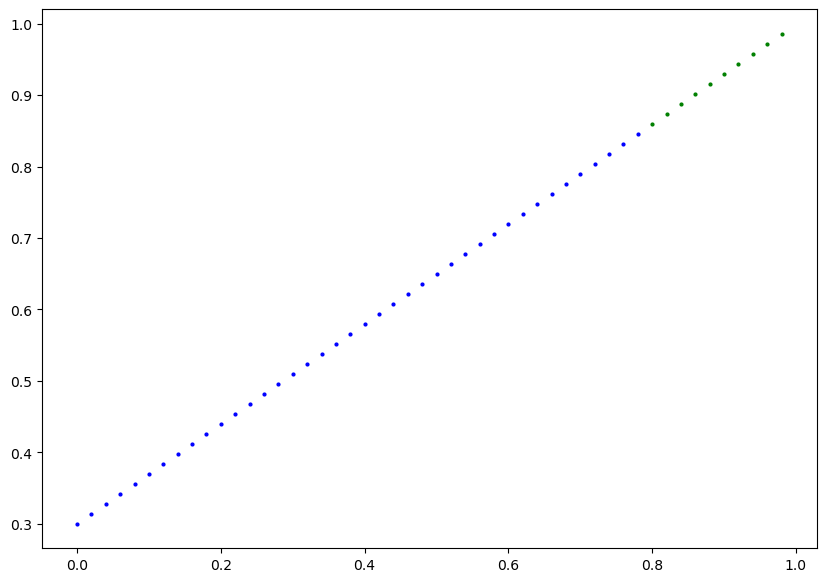

In [11]:
def plot_data(train_data=X_train,
              train_label=y_train,
              test_data=X_test,
              test_label=y_test,
              predictions=None):
    plt.figure(figsize=(10,7))

    #blue training data
    plt.scatter(train_data, train_label, c="b", s=4, label="training")

    #green test data
    plt.scatter(test_data, test_label, c="g", s=4, label="test")


    #predictions in red
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="predictions")





plot_data()

In [12]:
class LinearRegressionModel(nn.Module): #nn.Modules contains all neural network stuff
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
                                    #random weight first before training
                                                                    #update w grad descent
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    #forward is required by nn.Module class
    def forward(self, X:torch.Tensor) -> torch.Tensor:#x is input
        return self.weights*X+self.bias #how we compute the output given input


In [13]:
torch.manual_seed(42) #instead of random initial state we have a fixed one

model = LinearRegressionModel()
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [15]:
#making predictions
with torch.inference_mode():
    y_preds=model(X_test)
    #could be with torch.no_grad in old code

#using the inference mode makes forward pass (calculating actual predictions) faster

#ass predictions before learning
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

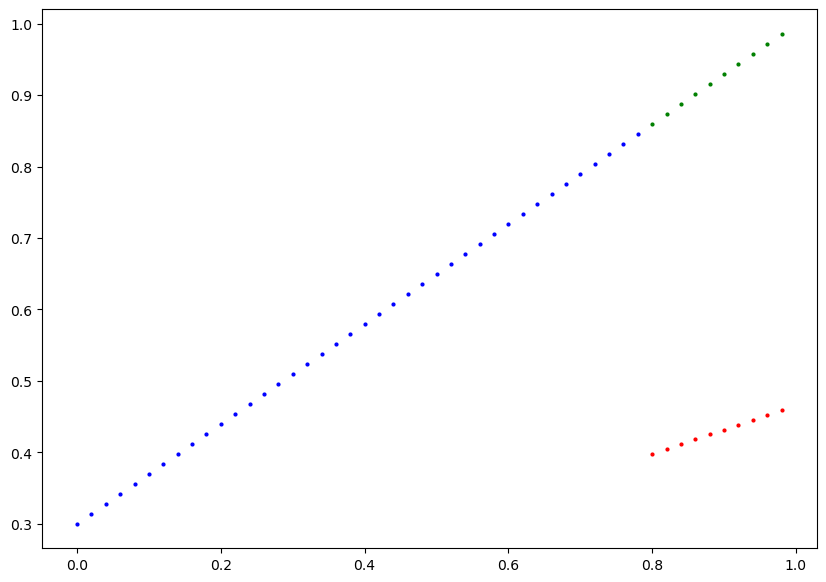

In [16]:
plot_data(predictions=y_preds)

In [17]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)
                            #params=prameters to optimise. lr=learningrate


In [18]:
#training loop:

epochs = 150

for epoch in range(epochs):

    #put in training mode
    model.train()
    #1 (forward pass): calculate current predictions
    y_pred = model(X_train)

    #2: calculate loss
    loss = loss_fn(y_pred, y_train)

    #3: reset gradient
    optimizer.zero_grad()

    #4: backpropagation on the loss
    loss.backward()

    #step optimiser
    optimizer.step()

    #test model

    #put model in evaluation mode
    model.eval()

    with torch.inference_mode():
        #1 forward pass on test data
        test_pred = model(X_test)

        #calculate loss on test
        test_loss = loss_fn(test_pred, y_test.type(torch.float)) #match the prediction datatype

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288135051727295 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713389158249 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.2172965705394745 
Epoch: 30 | MAE Train Loss: 0.053148530423641205 | MAE Test Loss: 0.14464019238948822 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953748226166 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633813381195 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937722325325 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.027887403964996338 | MAE Test Loss: 0.06473556160926819 
Epoch: 100 | MAE Train Loss: 0.024458955973386765 | MAE Test Loss: 0.056463055312633514 
Epoch: 110 | MAE Train Loss: 0.021020209416747093 | MA

OrderedDict([('weights', tensor([0.6638])), ('bias', tensor([0.3153]))])


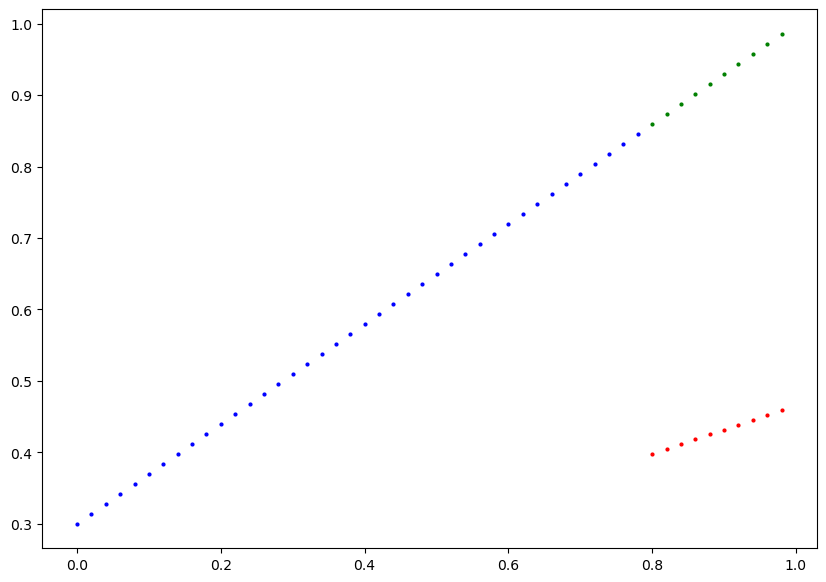

In [19]:
print(model.state_dict())
plot_data(predictions=y_preds)

In [20]:
#try without unsqueezing
start = 0
end = 1
step = 0.01
X = torch.arange(start, end, step)
y = 0.3 * X + 0.9

In [21]:
X

tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900, 0.1000, 0.1100, 0.1200, 0.1300, 0.1400, 0.1500, 0.1600, 0.1700,
        0.1800, 0.1900, 0.2000, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500, 0.2600,
        0.2700, 0.2800, 0.2900, 0.3000, 0.3100, 0.3200, 0.3300, 0.3400, 0.3500,
        0.3600, 0.3700, 0.3800, 0.3900, 0.4000, 0.4100, 0.4200, 0.4300, 0.4400,
        0.4500, 0.4600, 0.4700, 0.4800, 0.4900, 0.5000, 0.5100, 0.5200, 0.5300,
        0.5400, 0.5500, 0.5600, 0.5700, 0.5800, 0.5900, 0.6000, 0.6100, 0.6200,
        0.6300, 0.6400, 0.6500, 0.6600, 0.6700, 0.6800, 0.6900, 0.7000, 0.7100,
        0.7200, 0.7300, 0.7400, 0.7500, 0.7600, 0.7700, 0.7800, 0.7900, 0.8000,
        0.8100, 0.8200, 0.8300, 0.8400, 0.8500, 0.8600, 0.8700, 0.8800, 0.8900,
        0.9000, 0.9100, 0.9200, 0.9300, 0.9400, 0.9500, 0.9600, 0.9700, 0.9800,
        0.9900])

In [22]:
# train_split = int(len(X)*0.8)
# X_train, y_train = X[:train_split], y[:train_split]
# X_test, y_test = y[train_split:], y[train_split:]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

In [23]:
def plot(train_X, train_y, test_X, test_y, pred=None):
    plt.scatter(train_X, train_y, c="b", s=1, label="training")
    plt.scatter(test_X, test_y, c="g", s=1, label="test")

    if pred is not None:
        plt.scatter(X,pred, c="r", s=1, label="pred")

    plt.legend()
    plt.show()

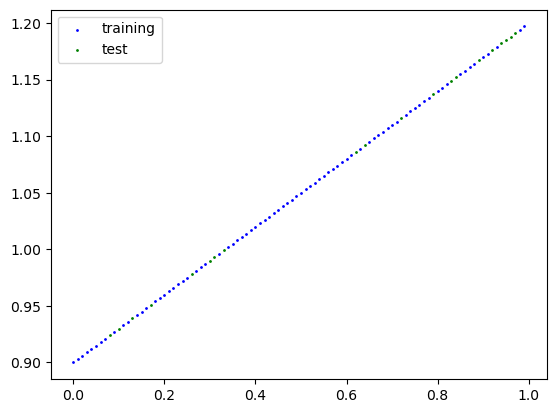

In [24]:
plot(X_train,y_train, X_test, y_test)

In [25]:
class test_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x):
        return self.weights * x + self.bias

model = test_model()

In [26]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [27]:
epochs = 200

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()

    if epoch % 10 == 0:
        with torch.inference_mode():
            test_pred = model(X_test)
            # print(test_pred.unsqueeze(dim=1))
            # print(y_test.unsqueeze(dim=1))
            test_loss = loss_fn(test_pred.unsqueeze(dim=1), y_test.unsqueeze(dim=1))
            print(test_loss)

tensor(0.6954)
tensor(0.5677)
tensor(0.4400)
tensor(0.3122)
tensor(0.1845)
tensor(0.0600)
tensor(0.0559)
tensor(0.0535)
tensor(0.0481)
tensor(0.0424)
tensor(0.0366)
tensor(0.0307)
tensor(0.0248)
tensor(0.0190)
tensor(0.0130)
tensor(0.0072)
tensor(0.0100)
tensor(0.0100)
tensor(0.0100)
tensor(0.0100)


OrderedDict([('weights', tensor([0.3050])), ('bias', tensor([0.8943]))])


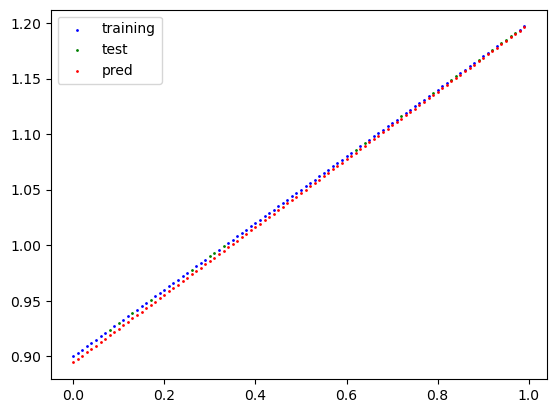

In [28]:

with torch.inference_mode():
    y_pred = model(X)
print(model.state_dict())
plot(X_train,y_train,X_test, y_test, y_pred)

In [29]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME
print(MODEL_SAVE_PATH)

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)


models/01_pytorch_workflow_model_1.pth


In [30]:
new_model = test_model()
new_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

print(new_model.state_dict())

OrderedDict([('weights', tensor([0.3050])), ('bias', tensor([0.8943]))])


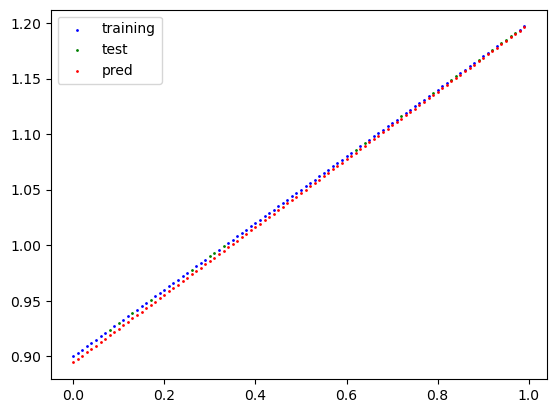

In [31]:
with torch.inference_mode():
    new_pred = new_model(X)

plot(X_train,y_train,X_test, y_test, new_pred)